# 用户购买预测 - 探索性数据分析 (EDA)

## 数据集概述
- **训练数据**: A 部分用户的购买数据 (6,989,817 条记录，483,117 个买家)
- **商品属性表**: 1,873,173 个商品的类目 id、店铺 id、加密价格等信息

## 数据特点
- 每个用户有至少 7 条购买数据
- 测试数据中每个用户的最后一条购买数据所对应的商品一定在训练数据中出现过
- 训练数据与测试数据中的用户集交为空

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 设置图表样式
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

In [25]:
train_df = pd.read_csv('data/Antai_hackathon_train.csv')
item_attr_df = pd.read_csv('data/Antai_hackathon_attr.csv')

print(f'训练数据形状：{train_df.shape}')
print(f'商品属性表形状：{item_attr_df.shape}')

训练数据形状：(6989817, 5)
商品属性表形状：(1924269, 4)


## 数据概览

In [26]:
print('训练数据')
display(train_df.head())

print('\n训练数据信息')
train_df.info()

print('\n训练数据统计描述')
display(train_df.describe())

训练数据


,buyer_country_id,buyer_admin_id,item_id,create_order_time,irank
0,xx,489859,1,2018-04-11 03:28:02,9
1,xx,2567786,2,2018-04-14 08:24:26,26
2,xx,3408746,3,2018-04-17 02:11:56,7
3,xx,2801580,4,2018-04-20 10:11:17,3
4,xx,1348149,5,2018-04-17 10:49:05,4



训练数据信息
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6989817 entries, 0 to 6989816
Data columns (total 5 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   buyer_country_id   object
 1   buyer_admin_id     int64 
 2   item_id            int64 
 3   create_order_time  object
 4   irank              int64 
dtypes: int64(3), object(2)
memory usage: 266.6+ MB

训练数据统计描述


,buyer_admin_id,item_id,irank
count,6.989817e+06,6.989817e+06,6.989817e+06
mean,3.793427e+06,3.792787e+06,2.932768e+01
std,2.190327e+06,2.189486e+06,3.023179e+02
min,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.896300e+06,1.896413e+06,4.000000e+00
50%,3.795519e+06,3.793176e+06,8.000000e+00
75%,5.689123e+06,5.689069e+06,1.300000e+01
max,7.585728e+06,7.585750e+06,1.176600e+04


In [27]:
print('商品属性表')
display(item_attr_df.head())

print('\n商品属性表信息')
item_attr_df.info()

print('\n商品属性表统计描述')
display(item_attr_df.describe())

商品属性表


,item_id,cate_id,store_id,item_price
0,140446,1413,11822,1
1,403593,2313,19712,1
2,252621,1682,6622,1
3,204530,1413,11822,1
4,340076,181,24403,1



商品属性表信息
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1924269 entries, 0 to 1924268
Data columns (total 4 columns):
 #   Column      Dtype
---  ------      -----
 0   item_id     int64
 1   cate_id     int64
 2   store_id    int64
 3   item_price  int64
dtypes: int64(4)
memory usage: 58.7 MB

商品属性表统计描述


,item_id,cate_id,store_id,item_price
count,1.924269e+06,1.924269e+06,1.924269e+06,1.924269e+06
mean,3.882977e+06,1.380070e+03,3.368103e+04,1.038872e+03
std,2.184653e+06,8.623223e+02,1.985649e+04,1.773790e+03
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,2.006722e+06,5.840000e+02,1.710700e+04,1.770000e+02
50%,3.926939e+06,1.416000e+03,3.282500e+04,4.130000e+02
75%,5.777812e+06,1.913000e+03,4.939000e+04,1.151000e+03
max,7.585751e+06,3.902000e+03,7.818600e+04,1.620100e+04


In [28]:
# 训练数据用户分析
print('训练数据用户统计')
train_user_stats = train_df.groupby('buyer_admin_id').agg({
    'item_id': 'count',
    'irank': ['min', 'max'],
    'create_order_time': ['min', 'max']
}).round(2)
train_user_stats.columns = ['购买次数', '最小 irank', '最大 irank', '首次购买时间', '末次购买时间']
display(train_user_stats.describe())

print(f'\n训练数据唯一买家数：{train_df["buyer_admin_id"].nunique()}')
print(f'训练数据总记录数：{len(train_df)}')
print(f'人均购买次数：{len(train_df) / train_df["buyer_admin_id"].nunique():.2f}')

训练数据用户统计


,购买次数,最小 irank,最大 irank
count,483117.000000,483117.0,483117.000000
mean,14.468166,1.0,14.468166
std,24.996817,0.0,24.996817
min,8.000000,1.0,8.000000
25%,9.000000,1.0,9.000000
50%,11.000000,1.0,11.000000
75%,15.000000,1.0,15.000000
max,11766.000000,1.0,11766.000000



训练数据唯一买家数：483117
训练数据总记录数：6989817
人均购买次数：14.47


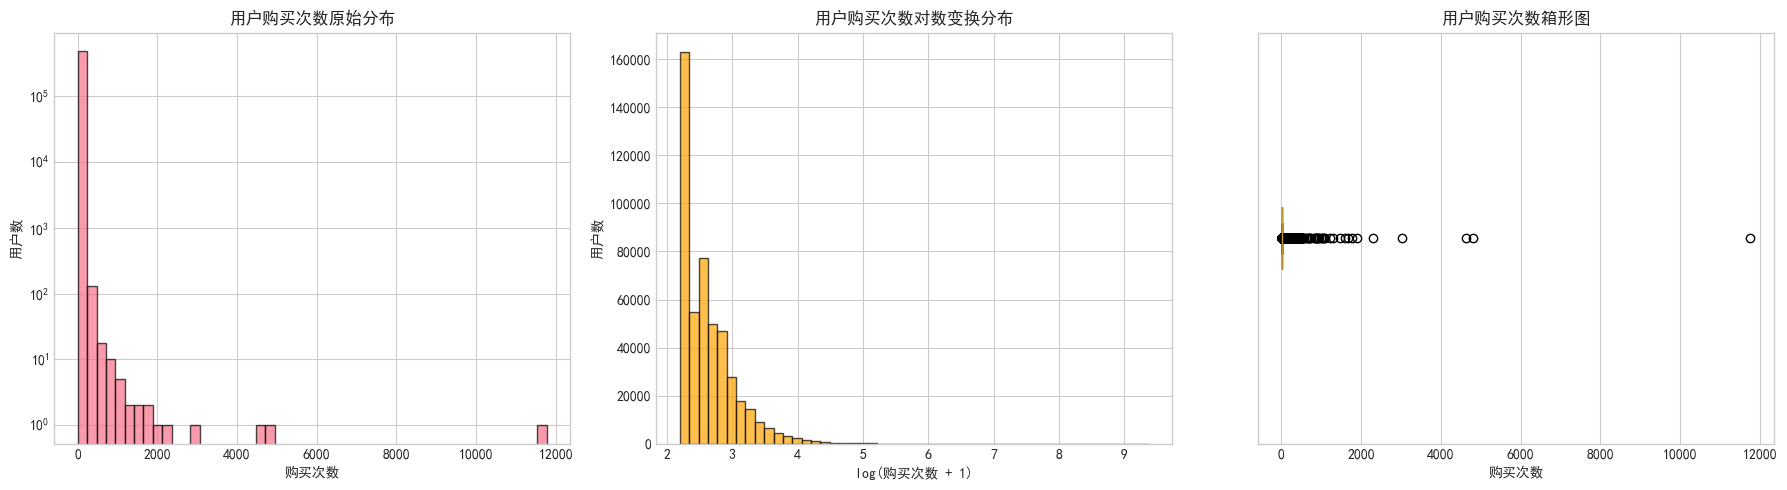


用户购买次数统计特征:
均值：14.47
中位数：11.00
标准差：25.00
最小值：8
最大值：11766
偏度：254.37
峰度：107169.24


In [29]:
# 用户购买次数分布可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 原始分布直方图
train_purchase_counts = train_df.groupby('buyer_admin_id').size()
axes[0].hist(train_purchase_counts, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('用户购买次数原始分布')
axes[0].set_xlabel('购买次数')
axes[0].set_ylabel('用户数')
axes[0].set_yscale('log')

# 2. 对数变换后的分布
log_purchase_counts = np.log1p(train_purchase_counts)
axes[1].hist(log_purchase_counts, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('用户购买次数对数变换分布')
axes[1].set_xlabel('log(购买次数 + 1)')
axes[1].set_ylabel('用户数')

# 3. 箱形图
axes[2].boxplot(train_purchase_counts.values, vert=False, patch_artist=True)
axes[2].set_title('用户购买次数箱形图')
axes[2].set_xlabel('购买次数')
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

# 统计特征
print(f'\n用户购买次数统计特征:')
print(f'均值：{train_purchase_counts.mean():.2f}')
print(f'中位数：{train_purchase_counts.median():.2f}')
print(f'标准差：{train_purchase_counts.std():.2f}')
print(f'最小值：{train_purchase_counts.min()}')
print(f'最大值：{train_purchase_counts.max()}')
print(f'偏度：{train_purchase_counts.skew():.2f}')
print(f'峰度：{train_purchase_counts.kurtosis():.2f}')


 长尾分布阈值与覆盖率分析 



,阈值,高频用户数,用户覆盖率 (%),订单覆盖率 (%),人均订单数
0,5,483117,100.00,100.00,14.47
1,10,320251,66.29,80.35,17.54
2,15,137999,28.56,50.21,25.43
3,20,71252,14.75,34.31,33.66
4,30,26117,5.41,19.20,51.40
5,50,7278,1.51,9.36,89.85
6,100,1435,0.30,3.93,191.57


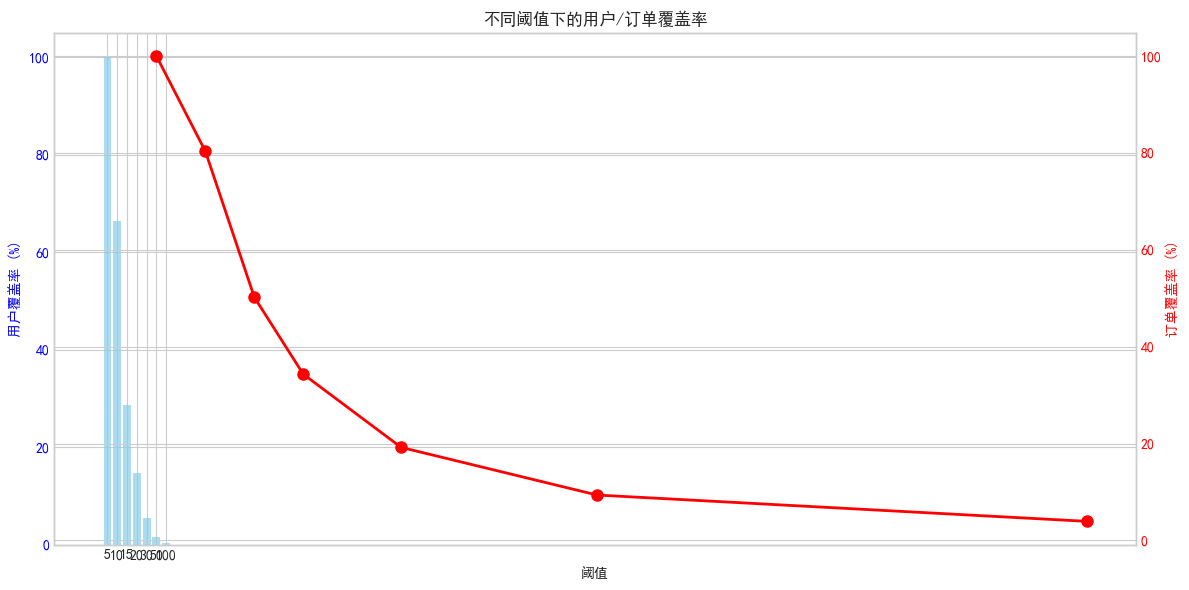


二八定律分析:
Top 65.78% 的用户贡献了 80% 的订单量
Top 20% 用户的订单占比：40.90%


In [30]:
# 长尾分布阈值与覆盖率分析
print('\n 长尾分布阈值与覆盖率分析 \n')

# 计算不同阈值下的覆盖率
thresholds = [5, 10, 15, 20, 30, 50, 100]
total_users = len(train_purchase_counts)
total_purchases = train_purchase_counts.sum()

coverage_data = []
for threshold in thresholds:
    high_freq_users = train_purchase_counts[train_purchase_counts >= threshold]
    high_freq_count = len(high_freq_users)
    high_freq_purchases = high_freq_users.sum()
    
    user_coverage = (high_freq_count / total_users) * 100
    purchase_coverage = (high_freq_purchases / total_purchases) * 100
    
    coverage_data.append({
        '阈值': threshold,
        '高频用户数': high_freq_count,
        '用户覆盖率 (%)': round(user_coverage, 2),
        '订单覆盖率 (%)': round(purchase_coverage, 2),
        '人均订单数': round(high_freq_purchases / high_freq_count, 2)
    })

coverage_df = pd.DataFrame(coverage_data)
display(coverage_df)

# 可视化覆盖率
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(coverage_df['阈值'].astype(str), coverage_df['用户覆盖率 (%)'], 
        alpha=0.7, color='skyblue', label='用户覆盖率')
ax1.set_xlabel('阈值')
ax1.set_ylabel('用户覆盖率 (%)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('不同阈值下的用户/订单覆盖率')

ax2 = ax1.twinx()
ax2.plot(coverage_df['阈值'], coverage_df['订单覆盖率 (%)'], 
         color='red', marker='o', linewidth=2, markersize=8, label='订单覆盖率')
ax2.set_ylabel('订单覆盖率 (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.tight_layout()
plt.show()

# 二八定律分析
sorted_counts = train_purchase_counts.sort_values(ascending=False)
cumulative_sum = sorted_counts.cumsum()
total_sum = sorted_counts.sum()

# 找出累计达到 80% 订单的用户比例
threshold_80 = cumulative_sum[cumulative_sum >= 0.8 * total_sum].index[0]
top_users_ratio = (sorted_counts.index.get_loc(threshold_80) + 1) / len(sorted_counts) * 100

print(f'\n二八定律分析:')
print(f'Top {top_users_ratio:.2f}% 的用户贡献了 80% 的订单量')
print(f'Top 20% 用户的订单占比：{(sorted_counts.head(int(len(sorted_counts)*0.2)).sum() / total_sum * 100):.2f}%')


 用户购买时间间隔分析 

已将 create_order_time 转换为 datetime 类型


,首次购买时间,末次购买时间,购买间隔天数,活跃天数
count,483117,483117,483117.000000,483117.000000
mean,2018-04-08 21:54:47.054568448,2018-04-21 14:18:30.145198848,12.253241,13.253241
min,2018-03-13 04:01:00,2018-03-17 11:13:41,0.000000,1.000000
25%,2018-04-03 14:43:13,2018-04-18 01:50:39,4.000000,5.000000
50%,2018-04-06 23:07:17,2018-04-23 13:15:32,13.000000,14.000000
75%,2018-04-12 12:18:40,2018-04-26 22:38:55,20.000000,21.000000
max,2018-04-28 23:58:04,2018-04-28 23:59:57,45.000000,46.000000
std,NaN,NaN,8.438550,8.438550



平均购买间隔：12.25 天
中位购买间隔：13.00 天
最长购买间隔：45 天
最短购买间隔：0 天


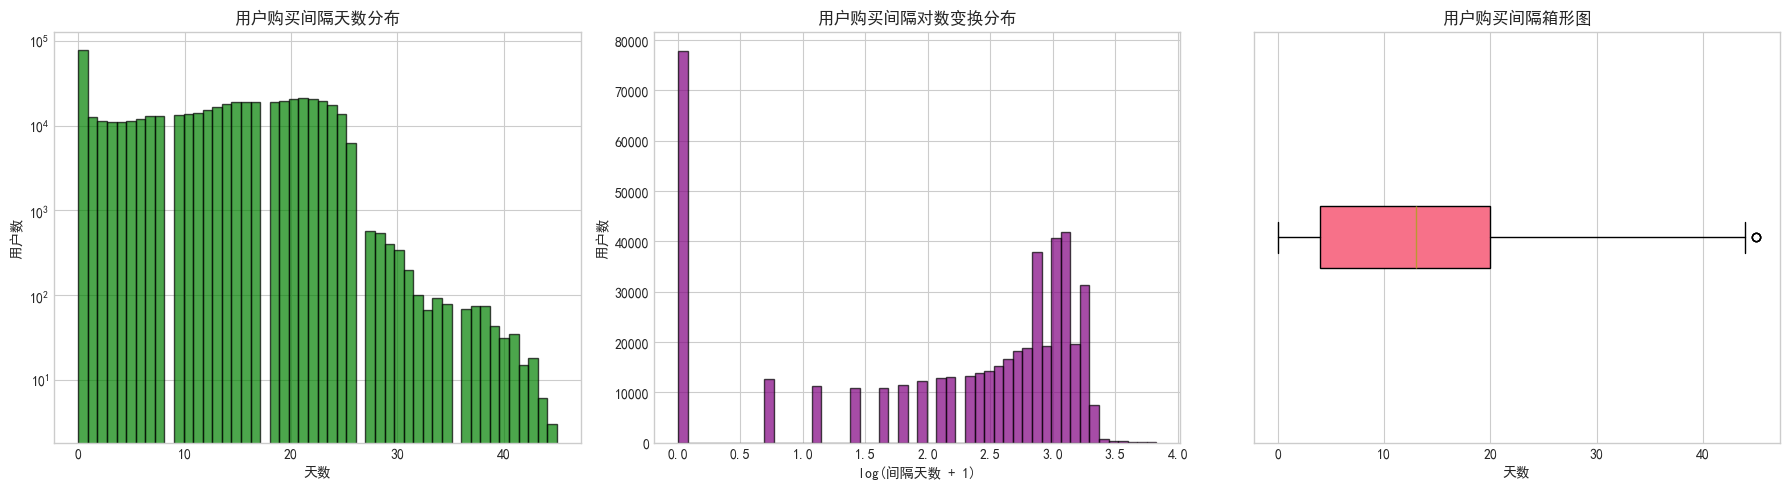

In [31]:
# 用户首次/末次购买时间间隔分析
print('\n 用户购买时间间隔分析 \n')

# 确保时间字段已转换
if train_df['create_order_time'].dtype == 'object':
    train_df['create_order_time'] = pd.to_datetime(train_df['create_order_time'])
    print('已将 create_order_time 转换为 datetime 类型')

# 计算每个用户的首次和末次购买时间
user_time_stats = train_df.groupby('buyer_admin_id')['create_order_time'].agg(['min', 'max'])
user_time_stats.columns = ['首次购买时间', '末次购买时间']

# 计算购买间隔（天数）
user_time_stats['购买间隔天数'] = (user_time_stats['末次购买时间'] - user_time_stats['首次购买时间']).dt.days
user_time_stats['活跃天数'] = user_time_stats['购买间隔天数'] + 1

display(user_time_stats.describe())

print(f'\n平均购买间隔：{user_time_stats["购买间隔天数"].mean():.2f} 天')
print(f'中位购买间隔：{user_time_stats["购买间隔天数"].median():.2f} 天')
print(f'最长购买间隔：{user_time_stats["购买间隔天数"].max()} 天')
print(f'最短购买间隔：{user_time_stats["购买间隔天数"].min()} 天')

# 购买间隔分布可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 原始间隔分布
axes[0].hist(user_time_stats['购买间隔天数'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0].set_title('用户购买间隔天数分布')
axes[0].set_xlabel('天数')
axes[0].set_ylabel('用户数')
axes[0].set_yscale('log')

# 2. 对数变换分布
log_interval = np.log1p(user_time_stats['购买间隔天数'])
axes[1].hist(log_interval, bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1].set_title('用户购买间隔对数变换分布')
axes[1].set_xlabel('log(间隔天数 + 1)')
axes[1].set_ylabel('用户数')

# 3. 箱形图
axes[2].boxplot(user_time_stats['购买间隔天数'].values, vert=False, patch_artist=True)
axes[2].set_title('用户购买间隔箱形图')
axes[2].set_xlabel('天数')
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

In [32]:
# 商品统计分析
print('训练数据商品统计 ')
print(f'唯一商品数：{train_df["item_id"].nunique()}')
print(f'总记录数：{len(train_df)}')
print(f'件均商品被购买次数：{len(train_df) / train_df["item_id"].nunique():.2f}')

print('\n商品属性表商品统计 ')
print(f'唯一商品数：{item_attr_df["item_id"].nunique()}')

训练数据商品统计 
唯一商品数：1852506
总记录数：6989817
件均商品被购买次数：3.77

商品属性表商品统计 
唯一商品数：1924269


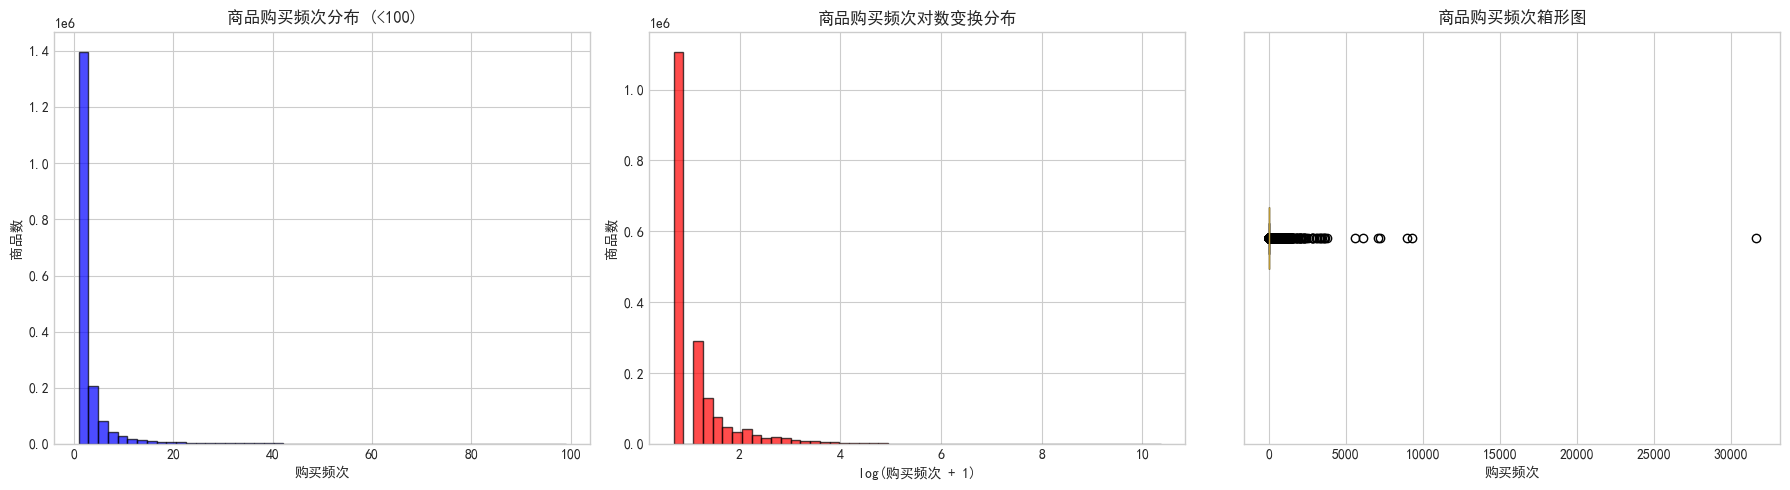


商品购买频次统计特征:
均值：3.77
中位数：1.00
标准差：32.91
最小值：1
最大值：31625
偏度：533.32
峰度：471257.52

训练数据 Top 20 热门商品 


item_id
7493101    31625
516873      9295
3964264     9006
7557509     7253
7482805     7078
3058048     6097
426022      5627
1872817     3770
413606      3672
6162363     3585
648691      3579
797627      3449
5421409     3405
1266501     3361
584059      3248
4163903     3115
928637      3091
564243      2910
7538392     2900
2982899     2840
dtype: int64

In [33]:
# 商品购买频次分布
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 训练数据商品购买频次
train_item_counts = train_df.groupby('item_id').size()

# 1. 原始分布（截断显示）
axes[0].hist(train_item_counts[train_item_counts < 100], bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0].set_title('商品购买频次分布 (<100)')
axes[0].set_xlabel('购买频次')
axes[0].set_ylabel('商品数')

# 2. 对数变换分布
log_item_counts = np.log1p(train_item_counts)
axes[1].hist(log_item_counts, bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1].set_title('商品购买频次对数变换分布')
axes[1].set_xlabel('log(购买频次 + 1)')
axes[1].set_ylabel('商品数')

# 3. 箱形图
axes[2].boxplot(train_item_counts.values, vert=False, patch_artist=True)
axes[2].set_title('商品购买频次箱形图')
axes[2].set_xlabel('购买频次')
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

# 统计特征
print(f'\n商品购买频次统计特征:')
print(f'均值：{train_item_counts.mean():.2f}')
print(f'中位数：{train_item_counts.median():.2f}')
print(f'标准差：{train_item_counts.std():.2f}')
print(f'最小值：{train_item_counts.min()}')
print(f'最大值：{train_item_counts.max()}')
print(f'偏度：{train_item_counts.skew():.2f}')
print(f'峰度：{train_item_counts.kurtosis():.2f}')

# Top 20 热门商品
print('\n训练数据 Top 20 热门商品 ')
top_train_items = train_item_counts.nlargest(20)
display(top_train_items)

In [34]:
# 转换时间字段
train_df['create_order_time'] = pd.to_datetime(train_df['create_order_time'])

# 提取时间特征
train_df['order_date'] = train_df['create_order_time'].dt.date
train_df['order_hour'] = train_df['create_order_time'].dt.hour
train_df['order_dayofweek'] = train_df['create_order_time'].dt.dayofweek
train_df['order_month'] = train_df['create_order_time'].dt.month

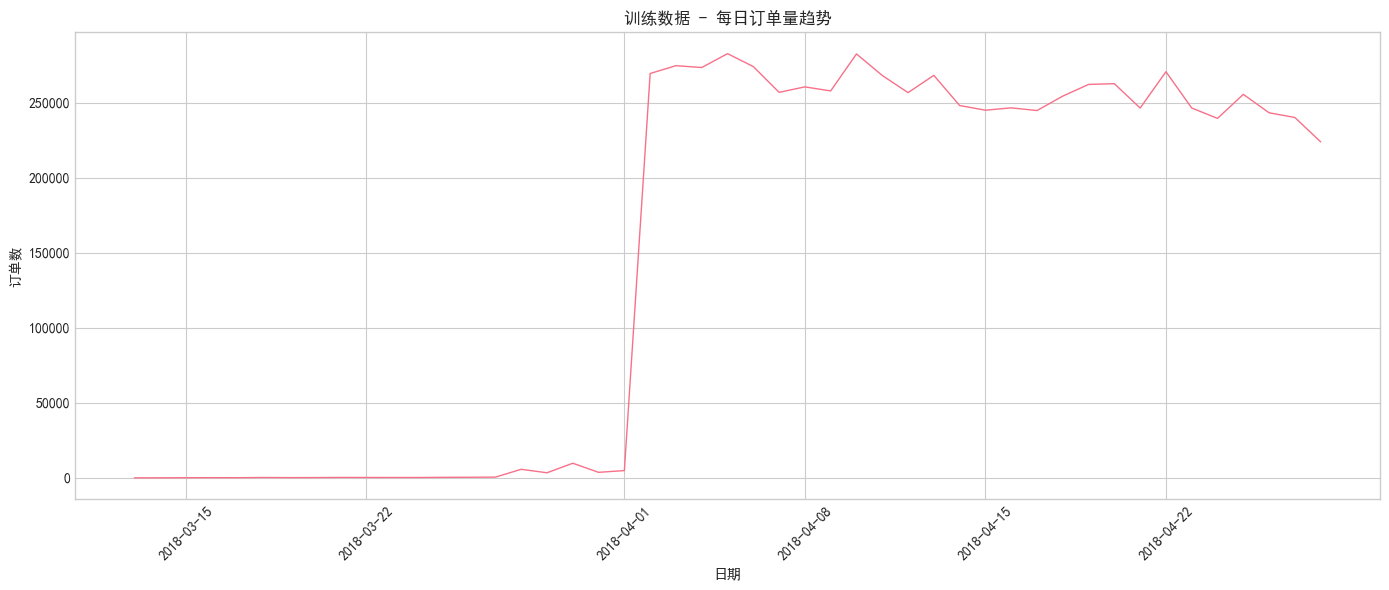

训练数据时间范围：2018-03-13 04:01:00 至 2018-04-28 23:59:57


In [35]:
# 日期分布分析
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# 训练数据每日订单量
train_daily_orders = train_df.groupby('order_date').size()
axes.plot(train_daily_orders.index, train_daily_orders.values, linewidth=1)
axes.set_title('训练数据 - 每日订单量趋势')
axes.set_xlabel('日期')
axes.set_ylabel('订单数')
axes.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'训练数据时间范围：{train_df["create_order_time"].min()} 至 {train_df["create_order_time"].max()}')

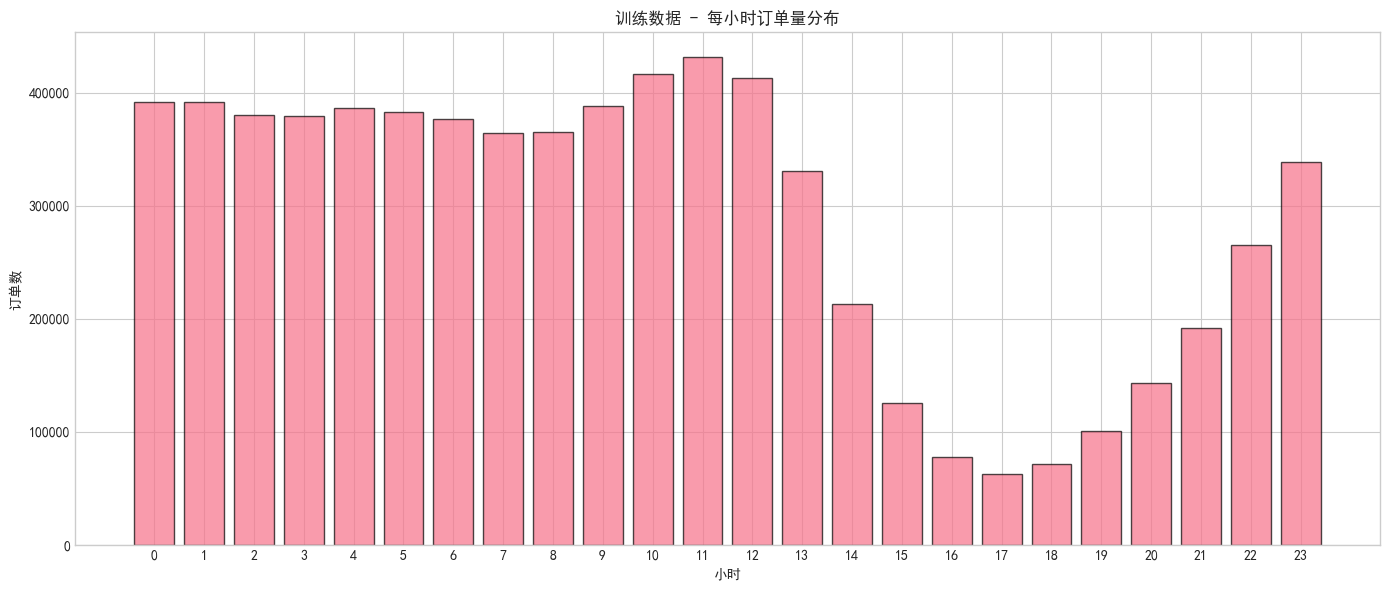


训练数据订单高峰时段：11点，订单数：431634
训练数据订单低谷时段：17点，订单数：62377


In [36]:
# 小时分布分析
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# 训练数据每小时订单量
train_hourly = train_df.groupby('order_hour').size()
axes.bar(train_hourly.index, train_hourly.values, alpha=0.7, edgecolor='black')
axes.set_title('训练数据 - 每小时订单量分布')
axes.set_xlabel('小时')
axes.set_ylabel('订单数')
axes.set_xticks(range(24))

plt.tight_layout()
plt.show()

# 高峰时段统计
print(f'\n训练数据订单高峰时段：{train_hourly.idxmax()}点，订单数：{train_hourly.max()}')
print(f'训练数据订单低谷时段：{train_hourly.idxmin()}点，订单数：{train_hourly.min()}')

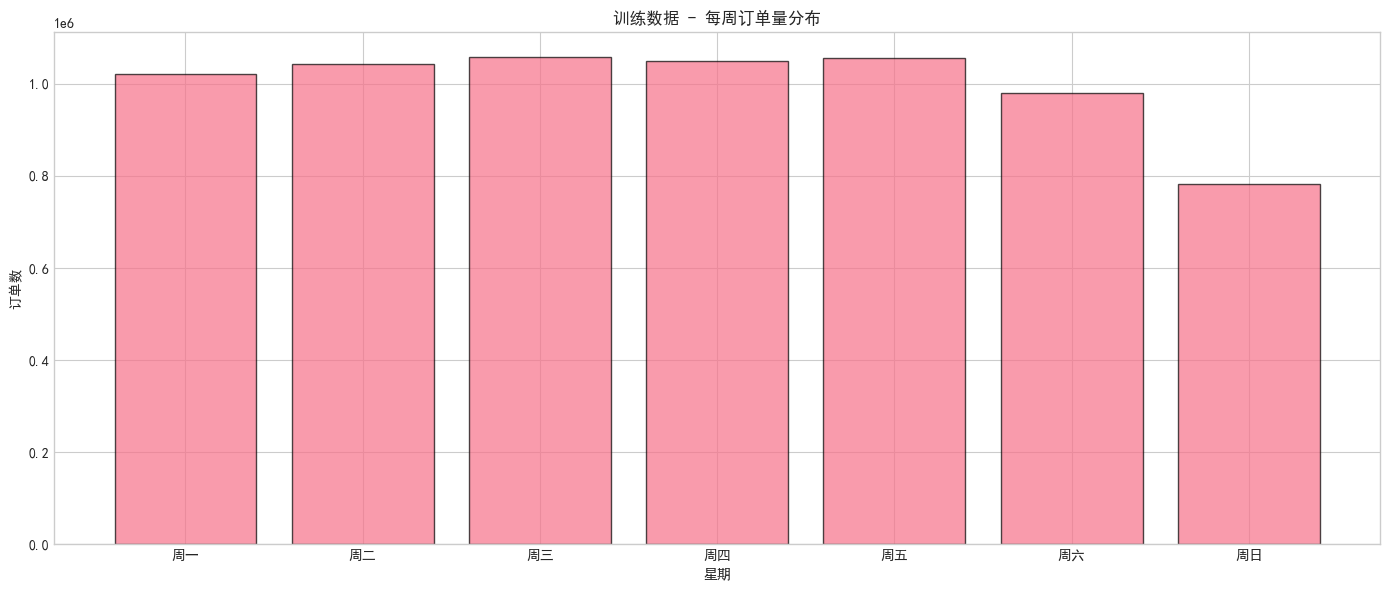


训练数据订单高峰日期：周三，订单数：1058226
训练数据订单低谷日期：周日，订单数：782131


In [37]:
# 星期分布分析
weekday_map = {0: '周一', 1: '周二', 2: '周三', 3: '周四', 4: '周五', 5: '周六', 6: '周日'}

fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# 训练数据每周订单量
train_weekday = train_df.groupby('order_dayofweek').size()
axes.bar([weekday_map[i] for i in train_weekday.index], train_weekday.values, 
            alpha=0.7, edgecolor='black')
axes.set_title('训练数据 - 每周订单量分布')
axes.set_xlabel('星期')
axes.set_ylabel('订单数')

plt.tight_layout()
plt.show()

print(f'\n训练数据订单高峰日期：{weekday_map[train_weekday.idxmax()]}，订单数：{train_weekday.max()}')
print(f'训练数据订单低谷日期：{weekday_map[train_weekday.idxmin()]}，订单数：{train_weekday.min()}')

In [38]:
# 商品类目分析
print(' 商品类目统计 ')
if 'cat_id' in item_attr_df.columns:
    print(f'唯一类目数：{item_attr_df["cat_id"].nunique()}')
    display(item_attr_df['cat_id'].describe())
    
    # Top 20 热门类目
    top_cats = item_attr_df['cat_id'].value_counts().nlargest(20)
    print('\n Top 20 热门类目 ')
    display(top_cats)
    
    # 可视化
    plt.figure(figsize=(14, 6))
    top_cats.plot(kind='bar', edgecolor='black')
    plt.title('Top 20 商品类目')
    plt.xlabel('类目 ID')
    plt.ylabel('商品数量')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

 商品类目统计 


 店铺统计 
唯一店铺数：78186


count    1.924269e+06
mean     3.368103e+04
std      1.985649e+04
min      1.000000e+00
25%      1.710700e+04
50%      3.282500e+04
75%      4.939000e+04
max      7.818600e+04
Name: store_id, dtype: float64


 Top 20 热门店铺 


store_id
1        4215
17033    1482
33081    1430
3723     1351
6087     1226
29716    1108
5939     1080
8618     1026
35919    1022
2750     1019
63790     993
48458     972
48288     946
29824     915
18907     911
59538     909
22443     896
8673      886
29456     879
29896     879
Name: count, dtype: int64

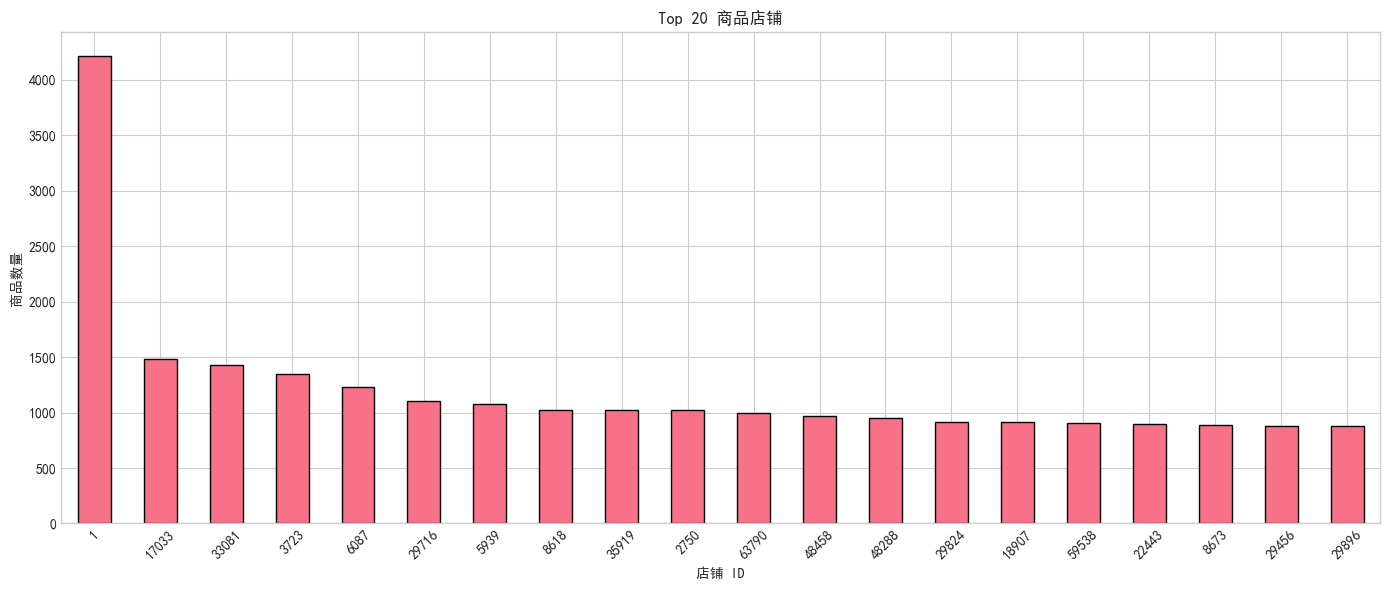

In [39]:
# 店铺分析
print(' 店铺统计 ')
if 'store_id' in item_attr_df.columns:
    print(f'唯一店铺数：{item_attr_df["store_id"].nunique()}')
    display(item_attr_df['store_id'].describe())
    
    # Top 20 热门店铺
    top_stores = item_attr_df['store_id'].value_counts().nlargest(20)
    print('\n Top 20 热门店铺 ')
    display(top_stores)
    
    # 可视化
    plt.figure(figsize=(14, 6))
    top_stores.plot(kind='bar', edgecolor='black')
    plt.title('Top 20 商品店铺')
    plt.xlabel('店铺 ID')
    plt.ylabel('商品数量')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()